In [3]:
import numpy as np
import matplotlib.pyplot as plt


In [4]:
import requests

baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":"af3b5de993fe7e78761a779e634dbbfa"}

def get(path, params=None):
    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically
    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename # return the filename string

    return r
r = get(baseUrl)
r.keys()

dict_keys(['simulations'])

In [5]:
len(r['simulations'])

66

In [6]:
names = [sim['name'] for sim in r['simulations']]
names

['Illustris-1',
 'Illustris-1-Dark',
 'Illustris-2',
 'Illustris-2-Dark',
 'Illustris-3',
 'Illustris-3-Dark',
 'TNG100-1',
 'TNG100-1-Dark',
 'TNG100-2',
 'TNG100-2-Dark',
 'TNG100-3',
 'TNG100-3-Dark',
 'TNG300-3',
 'TNG300-2-Dark',
 'TNG300-2',
 'TNG300-1-Dark',
 'TNG300-1',
 'TNG300-3-Dark',
 'TNG50-1',
 'TNG50-1-Dark',
 'TNG50-2',
 'TNG50-2-Dark',
 'TNG50-3',
 'TNG50-3-Dark',
 'TNG50-4',
 'TNG50-4-Dark',
 'TNG-Cluster',
 'Illustris-1-Subbox0',
 'Illustris-1-Subbox1',
 'Illustris-1-Subbox2',
 'Illustris-1-Subbox3',
 'Illustris-2-Subbox0',
 'Illustris-2-Subbox1',
 'Illustris-2-Subbox2',
 'Illustris-2-Subbox3',
 'Illustris-3-Subbox0',
 'Illustris-3-Subbox1',
 'Illustris-3-Subbox2',
 'Illustris-3-Subbox3',
 'TNG100-1-Subbox0',
 'TNG100-1-Subbox1',
 'TNG100-2-Subbox0',
 'TNG100-2-Subbox1',
 'TNG100-3-Subbox0',
 'TNG100-3-Subbox1',
 'TNG300-3-Subbox1',
 'TNG300-3-Subbox2',
 'TNG300-3-Subbox0',
 'TNG300-2-Subbox1',
 'TNG300-2-Subbox2',
 'TNG300-2-Subbox0',
 'TNG300-1-Subbox1',
 'TNG300-1

In [7]:
i=names.index('TNG100-1')
i

6

In [8]:
sim = get( r['simulations'][i]['url'] )
sim.keys()
sim['num_dm']

6028568000

In [9]:
sim['snapshots']
snaps = get( sim['snapshots'] )
len(snaps)

100

In [10]:
snaps[-1]

{'number': 99,
 'redshift': 2.22044604925031e-16,
 'num_groups_subfind': 4371211,
 'url': 'http://www.tng-project.org/api/TNG100-1/snapshots/99/'}

In [11]:
snap = get( snaps[-1]['url'] )
snap

{'simulation': 'http://www.tng-project.org/api/TNG100-1/',
 'number': 99,
 'redshift': 2.22044604925031e-16,
 'num_gas': 5453610043,
 'num_dm': 6028568000,
 'num_trmc': 12057136000,
 'num_stars': 453723346,
 'num_bhs': 37053,
 'num_groups_fof': 6291349,
 'num_groups_subfind': 4371211,
 'num_groups_rockstar': 0,
 'filesize_snapshot': 1852107755772.0,
 'filesize_groupcat': 4446214808.0,
 'filesize_rockstar': 0.0,
 'url': 'http://www.tng-project.org/api/TNG100-1/snapshots/99/',
 'subhalos': 'http://www.tng-project.org/api/TNG100-1/snapshots/99/subhalos/',
 'vis': {'groupcat_sfms': 'http://www.tng-project.org/api/TNG100-1/snapshots/99/subhalos/plot.png?xQuant=mstar2_log&yQuant=ssfr&xlim=9.0%2C11.0',
  'groupcat_sizemass': 'http://www.tng-project.org/api/TNG100-1/snapshots/99/subhalos/plot.png?xQuant=mstar2_log&yQuant=size_stars',
  'groupcat_mz_gas': 'http://www.tng-project.org/api/TNG100-1/snapshots/99/subhalos/plot.png?xQuant=mstar2_log&yQuant=Z_gas',
  'groupcat_mz_stars': 'http://www.t

In [12]:
subs = get( snap['subhalos'] )
subs.keys()

dict_keys(['count', 'next', 'previous', 'results'])

In [13]:
subs['count']
subs['next']
subs['previous']
subs['results']

[{'id': 0,
  'sfr': 2.22719,
  'mass_log_msun': 14.60813834636778,
  'url': 'http://www.tng-project.org/api/TNG100-1/snapshots/99/subhalos/0/'},
 {'id': 1,
  'sfr': 0.413285,
  'mass_log_msun': 13.733420710710462,
  'url': 'http://www.tng-project.org/api/TNG100-1/snapshots/99/subhalos/1/'},
 {'id': 2,
  'sfr': 17.3922,
  'mass_log_msun': 13.057590420489898,
  'url': 'http://www.tng-project.org/api/TNG100-1/snapshots/99/subhalos/2/'},
 {'id': 3,
  'sfr': 5.07938,
  'mass_log_msun': 12.699524859399856,
  'url': 'http://www.tng-project.org/api/TNG100-1/snapshots/99/subhalos/3/'},
 {'id': 4,
  'sfr': 1.41469,
  'mass_log_msun': 12.681528310672475,
  'url': 'http://www.tng-project.org/api/TNG100-1/snapshots/99/subhalos/4/'},
 {'id': 5,
  'sfr': 0.886559,
  'mass_log_msun': 12.643397303528015,
  'url': 'http://www.tng-project.org/api/TNG100-1/snapshots/99/subhalos/5/'},
 {'id': 6,
  'sfr': 2.18434,
  'mass_log_msun': 12.484770439405152,
  'url': 'http://www.tng-project.org/api/TNG100-1/snaps

In [14]:
mass_min = 10**9.0/ 1e10 * 0.704
mass_max = 10**10.5 / 1e10 * 0.704
search_query = "?mass__gt=" + str(mass_min) + "&mass__lt=" + str(mass_max)
search_query

'?mass__gt=0.0704&mass__lt=2.2262434727585387'

In [15]:
url = "http://www.tng-project.org/api/TNG100-1/snapshots/z=0/subhalos/" + search_query
subhalos = get(url)
subhalos['count']

968555

In [16]:
ids = [ subhalos['results'][i]['id'] for i in range(20) ]
ids

[89,
 108,
 152,
 156,
 162,
 173,
 179,
 206,
 208,
 215,
 216,
 221,
 224,
 231,
 237,
 238,
 241,
 242,
 243,
 244]

In [22]:
sub = get(subhalos['results'][11]['url'])   
sub

{'snap': 99,
 'id': 221,
 'bhmdot': 0.0,
 'cm_x': 913.653,
 'cm_y': 25931.0,
 'cm_z': 18255.1,
 'gasmetallicity': 0.0,
 'gasmetallicityhalfrad': 0.0,
 'gasmetallicitymaxrad': 0.0,
 'gasmetallicitysfr': 0.0,
 'gasmetallicitysfrweighted': 0.0,
 'pos_x': 913.741,
 'pos_y': 25931.2,
 'pos_z': 18254.9,
 'halfmassrad': 4.8927,
 'halfmassrad_gas': 0.0,
 'halfmassrad_dm': 5.2149,
 'halfmassrad_stars': 2.7545,
 'halfmassrad_bhs': 0.0,
 'len': 7899,
 'len_gas': 0,
 'len_dm': 3869,
 'len_stars': 4030,
 'len_bhs': 0,
 'mass': 2.21905,
 'mass_gas': 0.0,
 'mass_dm': 1.95607,
 'mass_stars': 0.262982,
 'mass_bhs': 0.0,
 'massinhalfrad': 0.611245,
 'massinhalfrad_gas': 0.0,
 'massinhalfrad_dm': 0.47979,
 'massinhalfrad_stars': 0.131455,
 'massinhalfrad_bhs': 0.0,
 'massinmaxrad': 0.993477,
 'massinmaxrad_gas': 0.0,
 'massinmaxrad_dm': 0.813469,
 'massinmaxrad_stars': 0.180008,
 'massinmaxrad_bhs': 0.0,
 'massinrad': 1.23272,
 'massinrad_gas': 0.0,
 'massinrad_dm': 1.02783,
 'massinrad_stars': 0.204887,

In [24]:
import h5py
from mpl_toolkits.mplot3d import Axes3D


cutout_url = sub['cutouts']['subhalo']
print(f"Cutout URL: {cutout_url}")


filename = get(cutout_url)   
print(f"Downloaded: {filename}")




Cutout URL: http://www.tng-project.org/api/TNG100-1/snapshots/99/subhalos/221/cutout.hdf5
Downloaded: cutout_221.hdf5


In [25]:
with h5py.File(filename, 'r') as f:
    coords = f['PartType1/Coordinates'][:] 
    print(f"暗物质粒子数量: {len(coords)}")


暗物质粒子数量: 3869


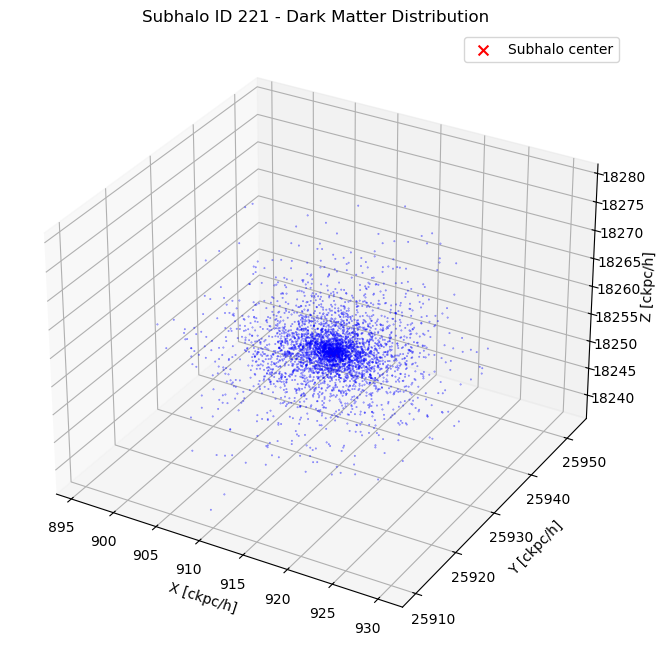

In [ ]:


x, y, z = coords[:, 0], coords[:, 1], coords[:, 2]


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')


ax.scatter(x, y, z, s=0.5, c='blue', alpha=0.6, marker='.')


center_x = sub['pos_x']
center_y = sub['pos_y']
center_z = sub['pos_z']
ax.scatter(center_x, center_y, center_z, c='red', s=50, marker='x',label='Subhalo center')


ax.set_xlabel('X [ckpc/h]')
ax.set_ylabel('Y [ckpc/h]')
ax.set_zlabel('Z [ckpc/h]')
ax.set_title(f'Subhalo ID {sub["id"]} - Dark Matter Distribution ')
ax.legend()

plt.show()